In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Desenvolvimento

In [ ]:

# function to print the simulated operational domain
def print_operational_domain_epsilon_lambda(basepath, gate, title=None):
    extra_points = [
        (5.6, 5),
        (4.1, 1.8)
    ]
    real_title = title if title else gate.replace("_", " ").title()
    
    plt.figure(figsize=(6, 6))
    mus = [(-0.32, "blueviolet"), (-0.28, "pink")]
    for (mu, color) in mus:
    # Read data from CSV file
        data = None
        try:
            data = pd.read_csv(f"{basepath}/operational_domain_flood_fill_siqad_{mu:.2f}_{gate}.csv")
        except:
            try:
                data = pd.read_csv(f"{basepath}/operational_domain_contour_tracing_siqad_{mu:.2f}_{gate}.csv")
            except:
                print(f"Operational Domain file not found for mu={mu} and gate={gate}.")
                continue
        
        # Separate data based on operational status
        operational_data = data[data["operational status"] == 1]
        
        # Extract epsilon_r and lambda_tf values for each group
        epsilon_r_operational = operational_data["epsilon_r"]
        lambda_tf_operational = operational_data["lambda_tf"]
        
        # Plot the data with different colors for each group
        plt.plot(epsilon_r_operational, lambda_tf_operational, "s", markersize=2, color=color, label=f"operational (mu={mu:.2f})", alpha=0.6)
        
    plt.xlabel(r'$\epsilon_r$', fontsize=18)
    plt.ylabel(r'$\lambda_{tf}$ [nm]', fontsize=18)
    plt.xlim(1, 10)
    plt.ylim(1, 10)
    plt.grid(False)
    # set the tick font size
    plt.tick_params(labelsize=15)
    plt.legend(fontsize=12)
    plt.title(real_title, fontsize=18)

    new=[]
    old=[]
    for point in extra_points:
        for (mu, color) in reversed(mus):
            try:
                temps = pd.read_csv(f"{basepath}/critical_temperature_{mu:.2f}_{gate}.csv")
                old.append(temps.loc[0, 'Critical Temperature (Old)'])
                new.append(temps.loc[0, 'Critical Temperature (New)'])
            except:
                print(f"Critical temperature file not found for mu={mu}, gate={gate} and point={point}.")
                old.append('-')
                new.append('-')


        plt.plot(point[0], point[1], "+", markersize=10, color="black")
        plt.text(point[0] + 0.1, point[1] + 0.1, f"({point[0]}, {point[1]})", fontsize=12, color="black")

        # Critical temperature when mu is (-0.28, -0.32) respectively
        plt.text(extra_points[0][0], extra_points[0][1] + 0.5, f"({old[0]}K, {old[1]}K)", fontsize=12, color="black", weight="bold")
        plt.text(extra_points[1][0], extra_points[1][1] + 0.5, f"({new[0]}K, {new[1]}K)", fontsize=12, color="black", weight="bold")

    plt.show()

Wire2 Horizontal Acs gates: ['wire2_3_horizontal_ACS', 'wire2_4_horizontal_ACS', 'wire2_5_horizontal_ACS', 'wire2_6_horizontal_ACS', 'wire2_7_horizontal_ACS', 'wire2_8_horizontal_ACS', 'wire2_9_horizontal_ACS', 'wire2_10_horizontal_ACS']


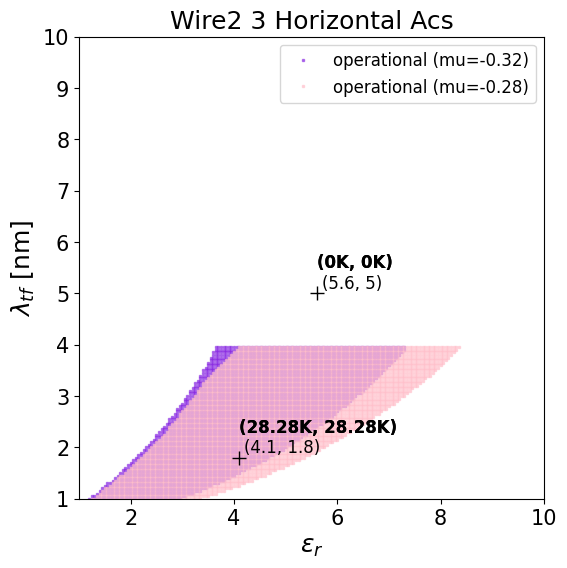

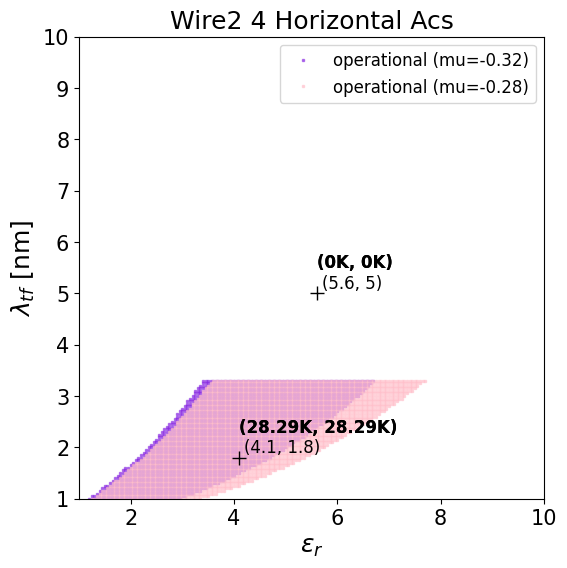

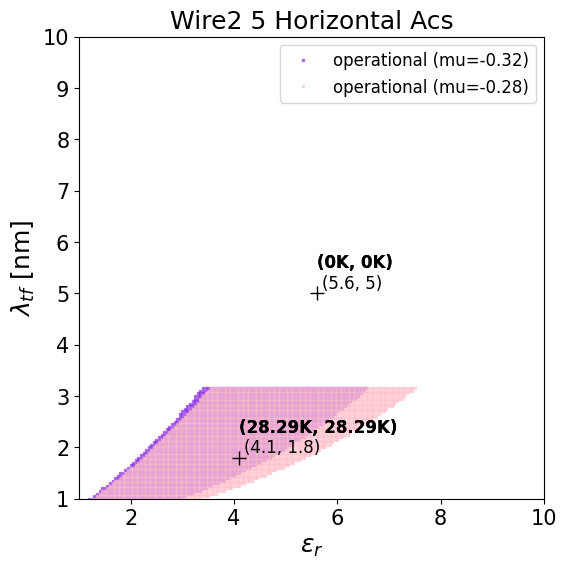

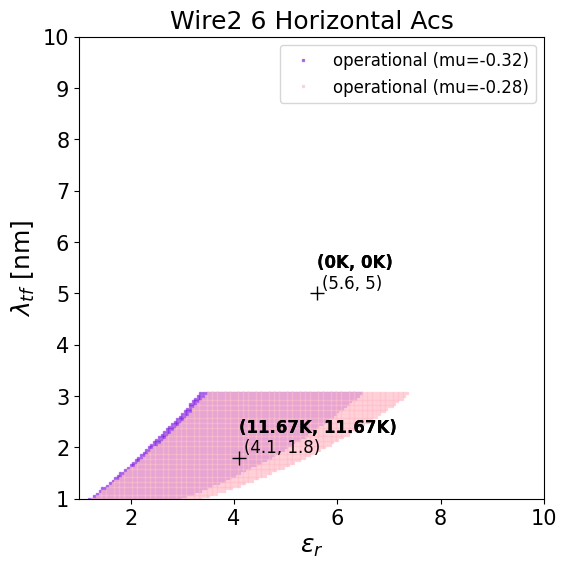

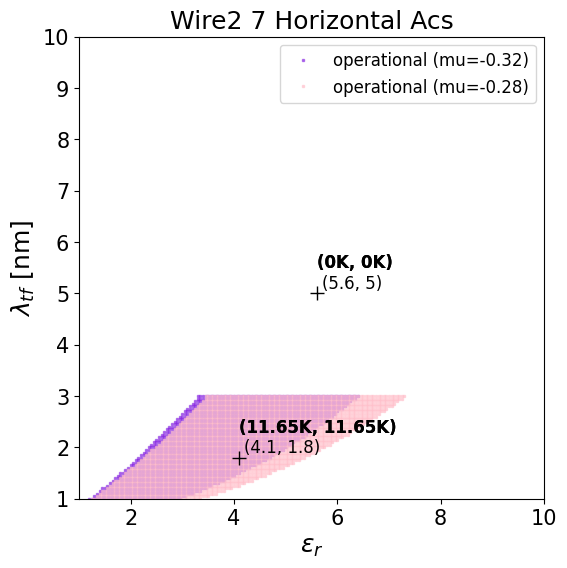

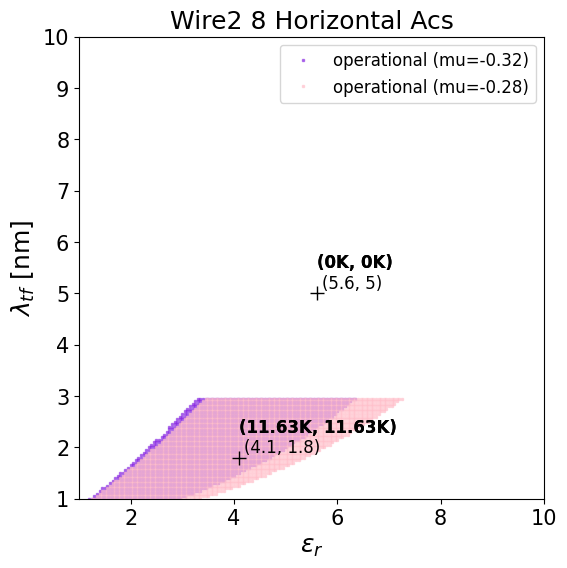

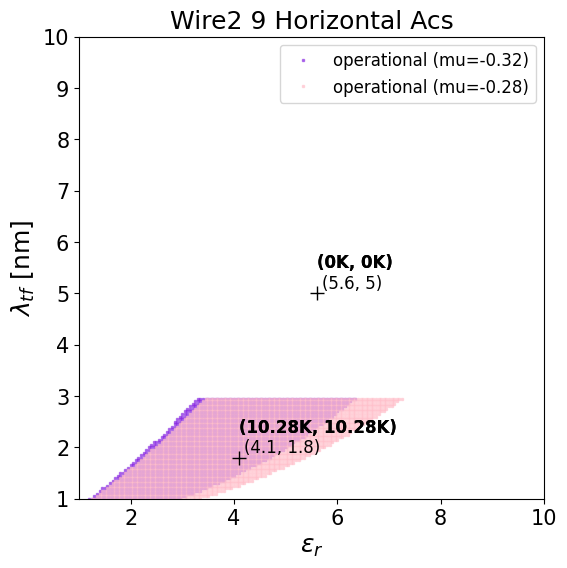

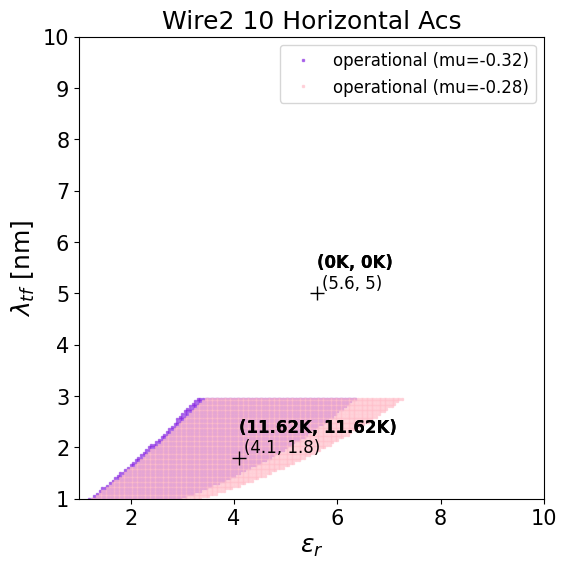

Wire Diagonal gates: ['wire_3_diagonal', 'wire_4_diagonal', 'wire_5_diagonal', 'wire_6_diagonal', 'wire_7_diagonal', 'wire_8_diagonal', 'wire_9_diagonal', 'wire_10_diagonal']


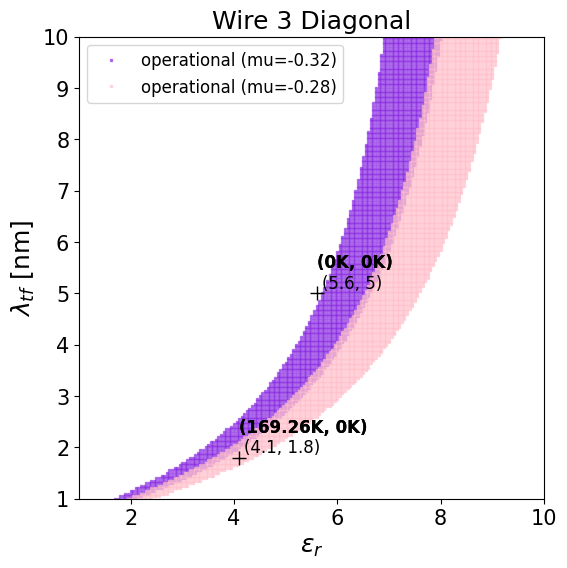

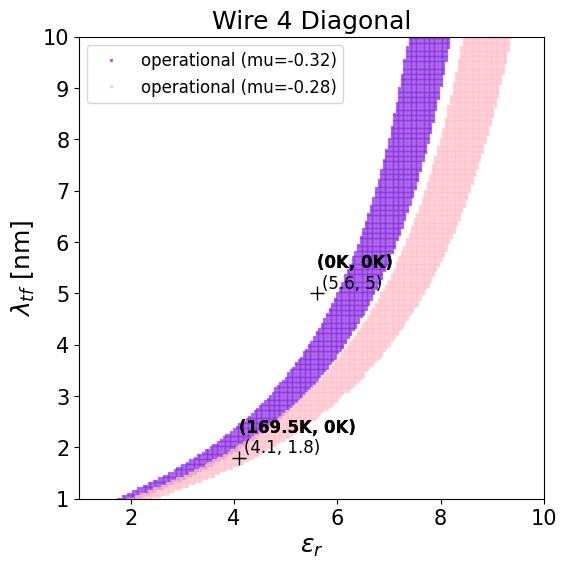

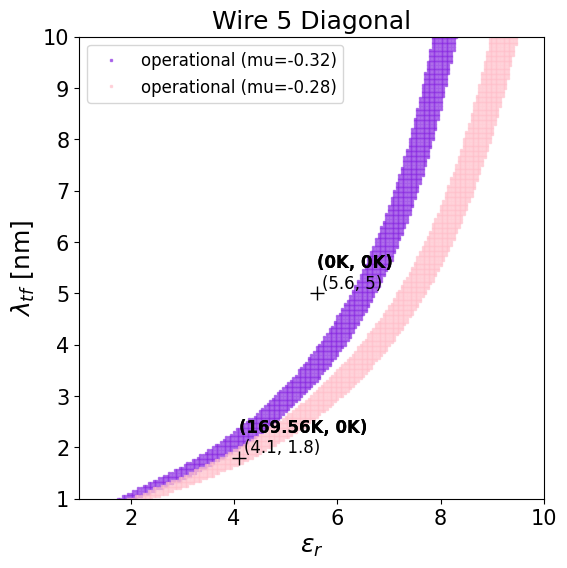

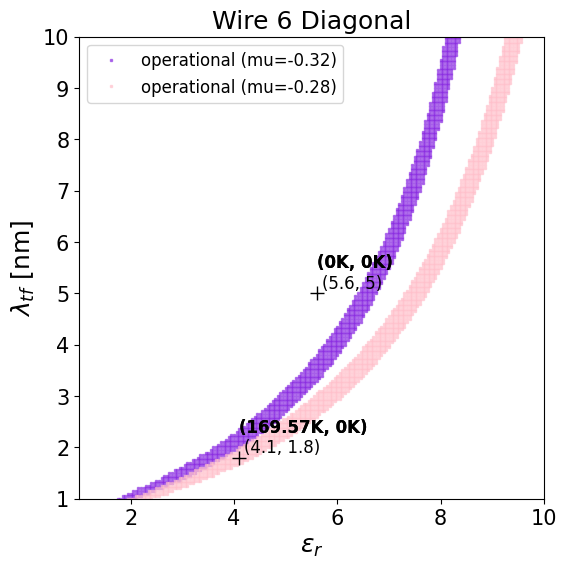

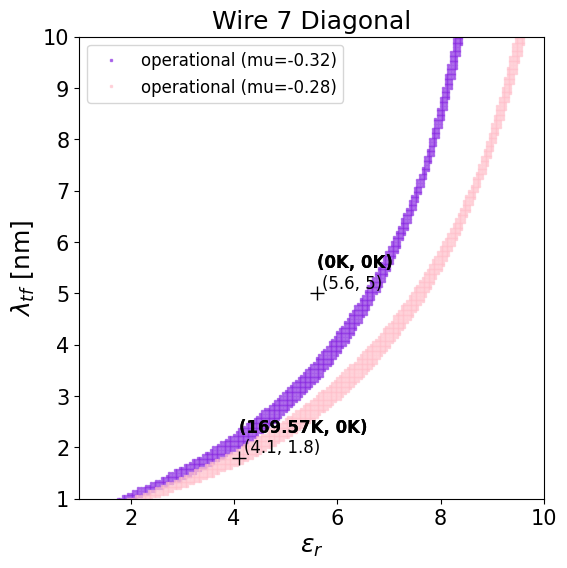

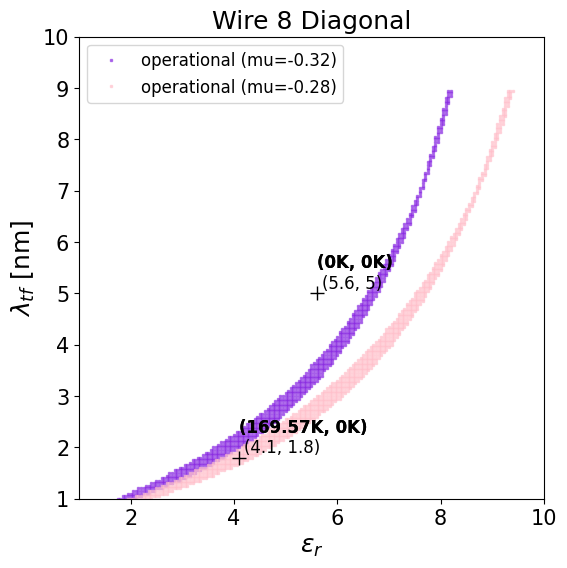

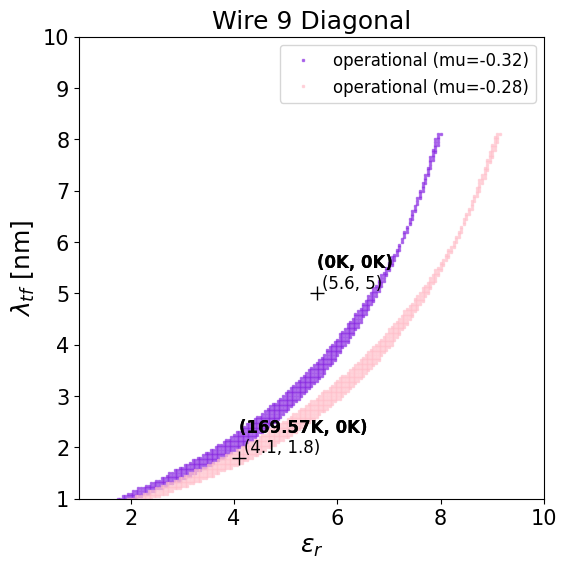

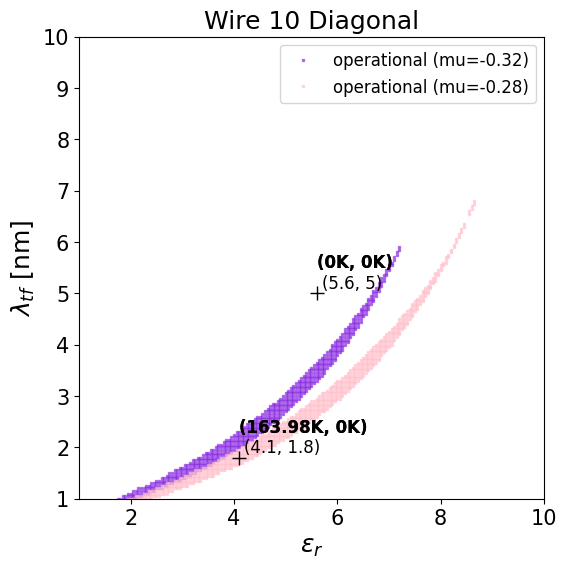

Wire2 Diagonal Acs gates: ['wire2_3_diagonal_ACS', 'wire2_4_diagonal_ACS', 'wire2_5_diagonal_ACS', 'wire2_6_diagonal_ACS', 'wire2_7_diagonal_ACS', 'wire2_8_diagonal_ACS', 'wire2_9_diagonal_ACS', 'wire2_10_diagonal_ACS']


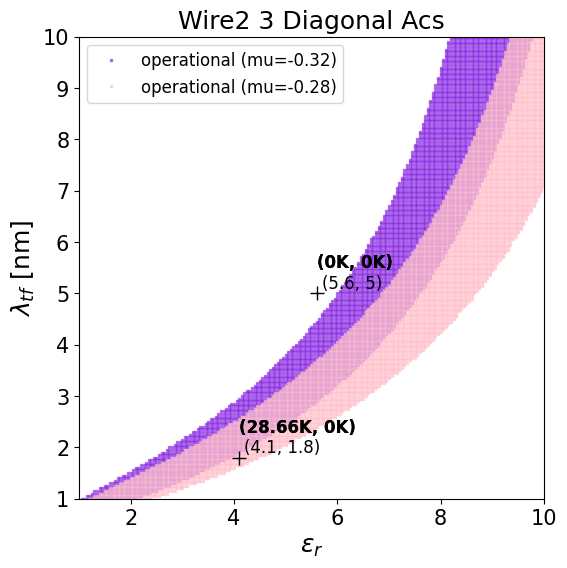

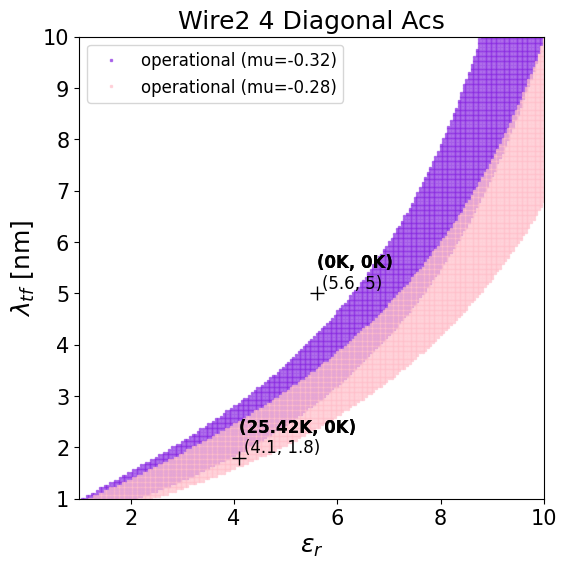

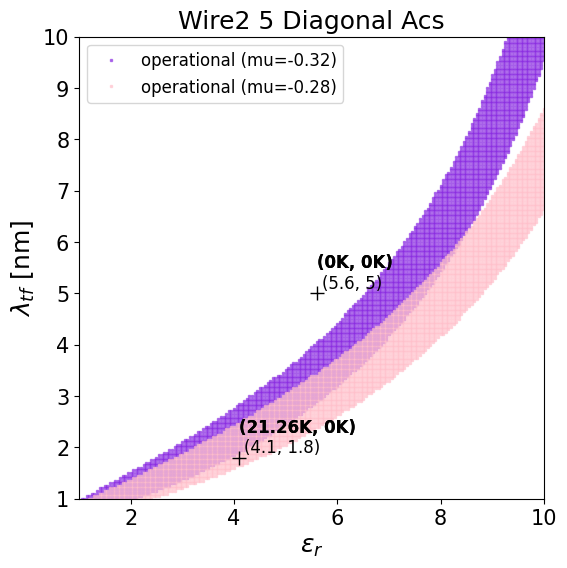

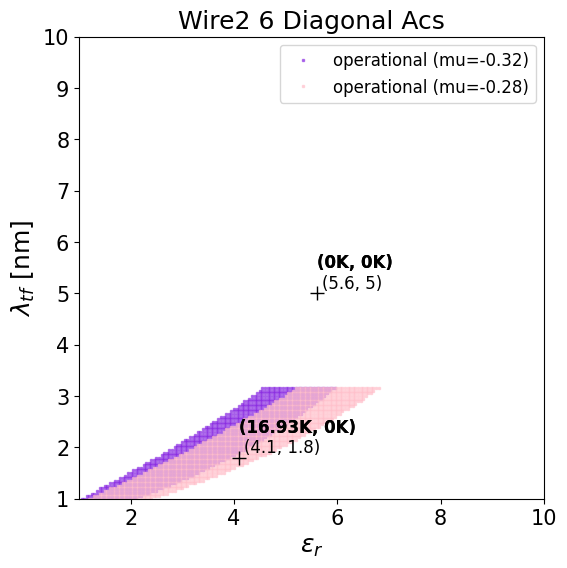

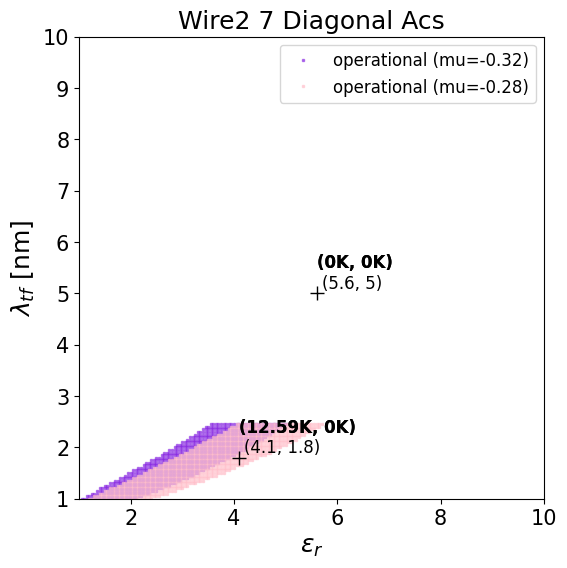

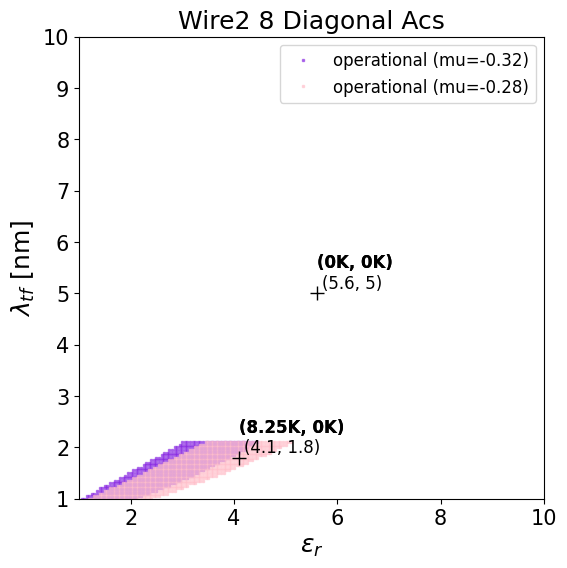

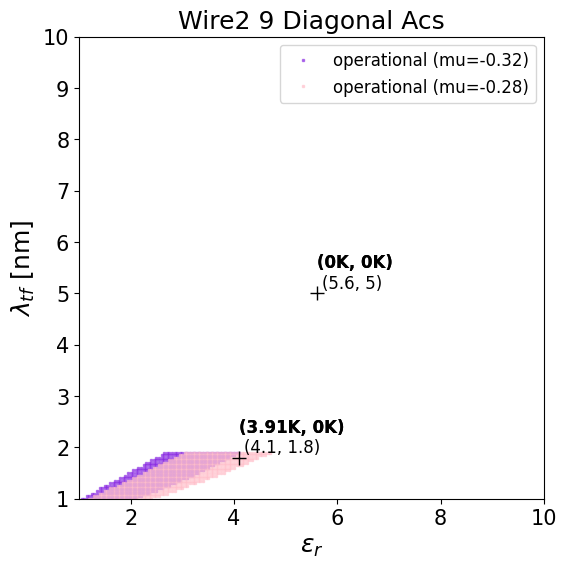

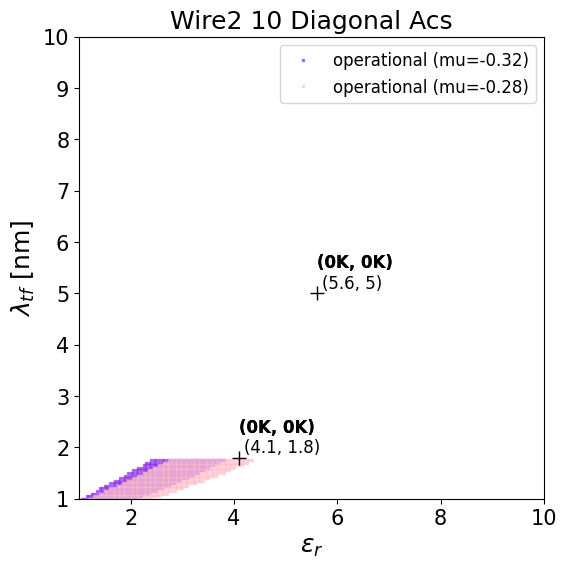

Wire Diagonal Acs gates: ['wire_3_diagonal_ACS', 'wire_4_diagonal_ACS', 'wire_5_diagonal_ACS', 'wire_6_diagonal_ACS', 'wire_7_diagonal_ACS', 'wire_8_diagonal_ACS', 'wire_9_diagonal_ACS', 'wire_10_diagonal_ACS']


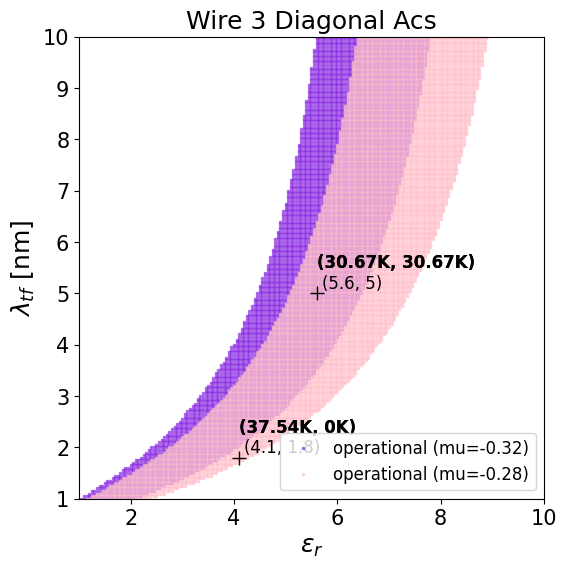

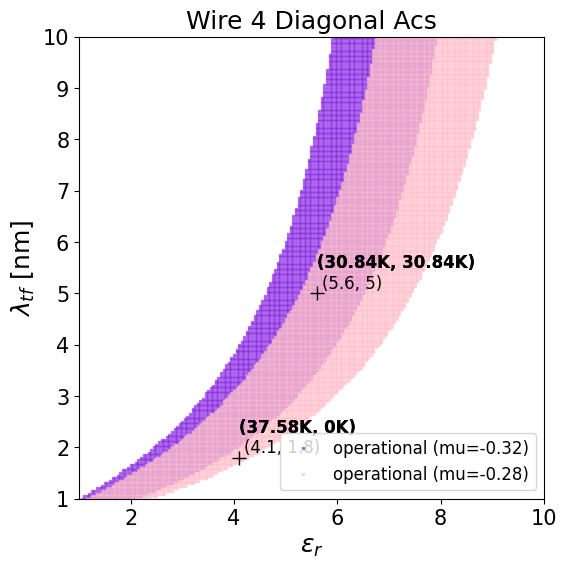

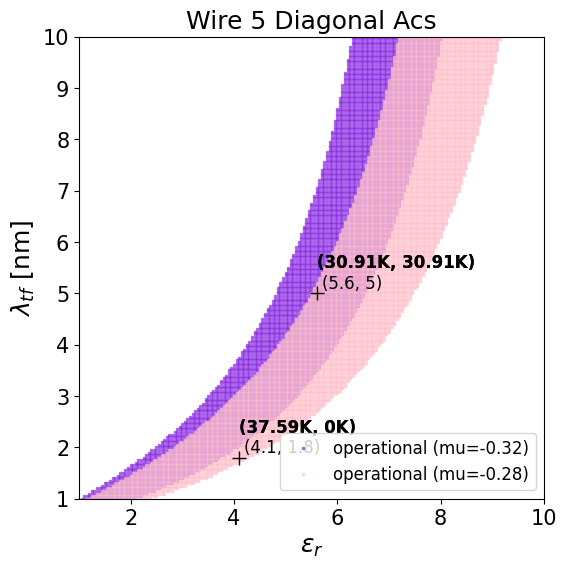

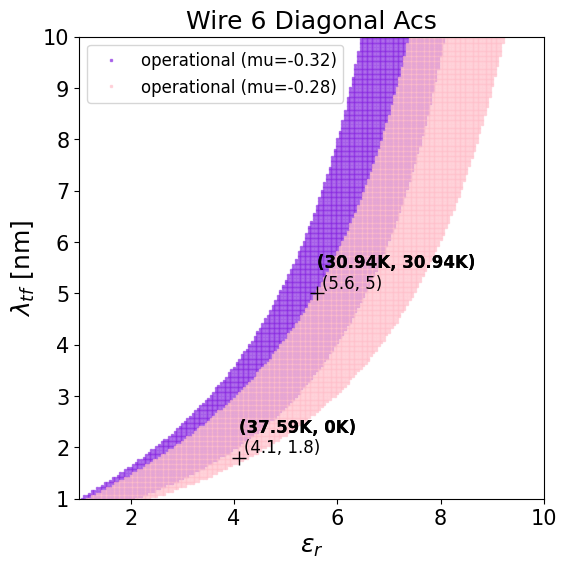

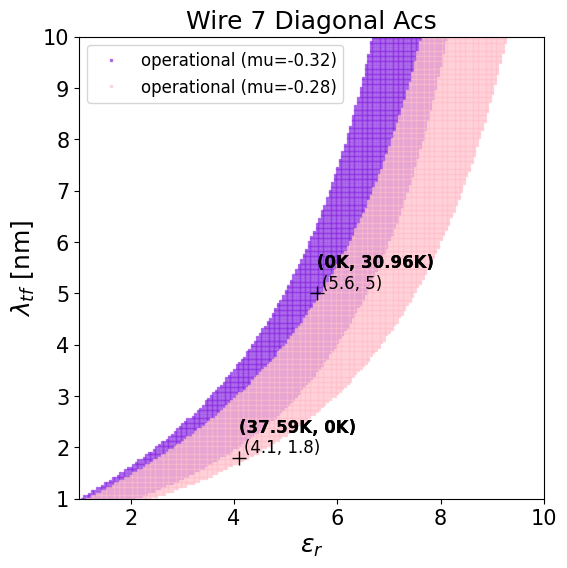

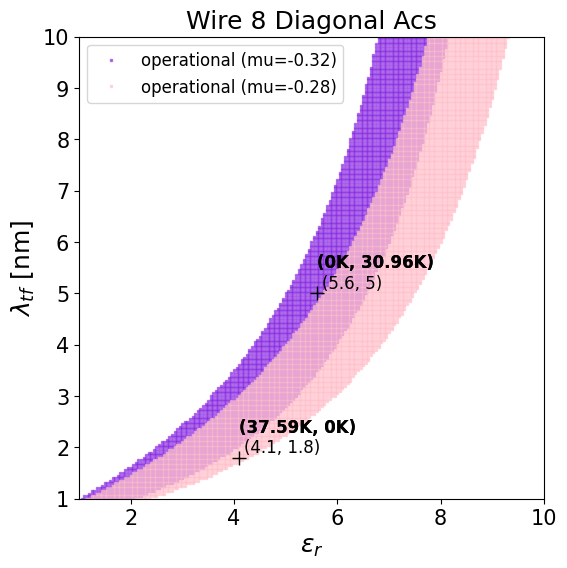

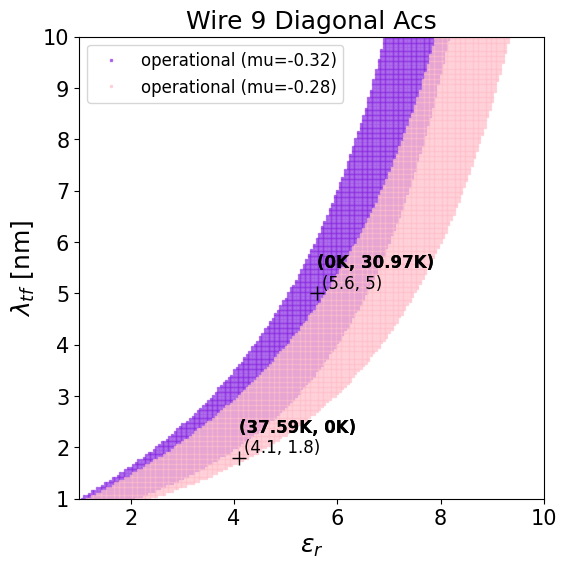

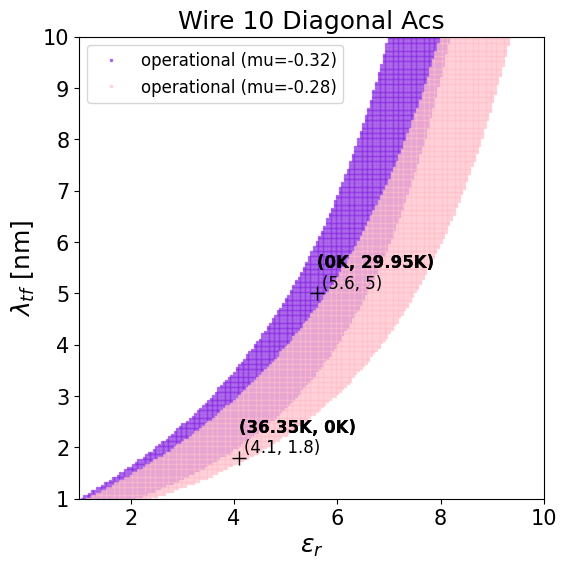

Wire Horizontal gates: ['wire_3_horizontal', 'wire_4_horizontal', 'wire_5_horizontal', 'wire_6_horizontal', 'wire_7_horizontal', 'wire_8_horizontal', 'wire_9_horizontal', 'wire_10_horizontal']


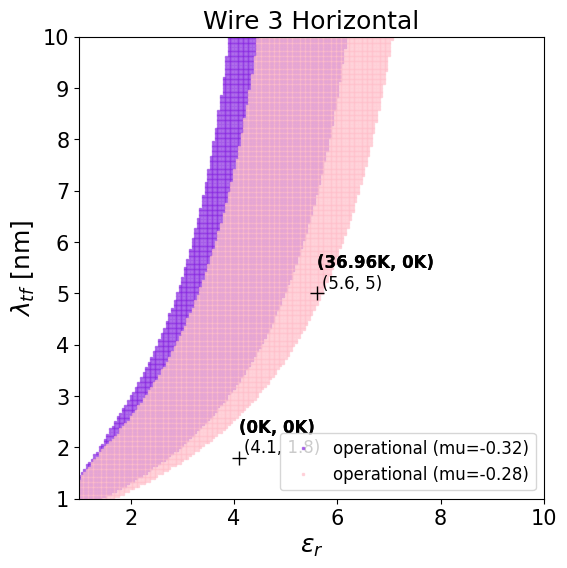

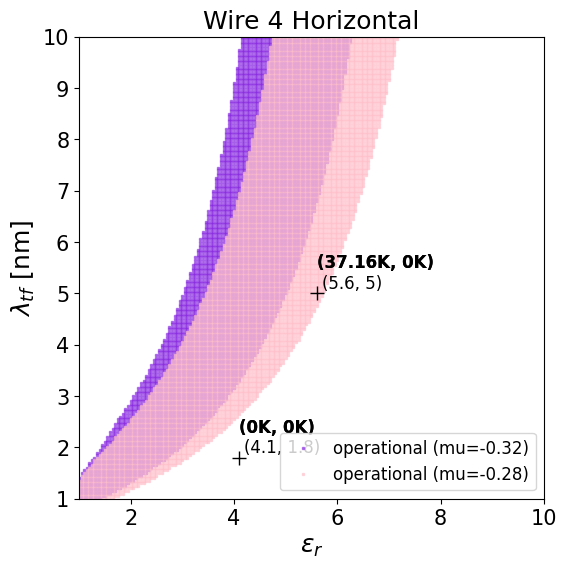

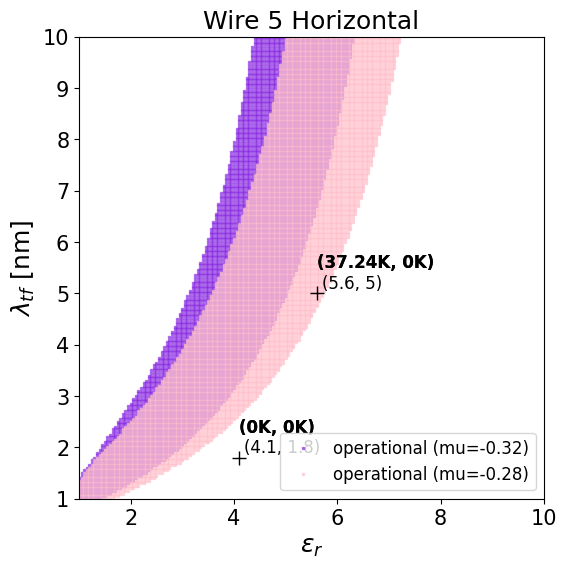

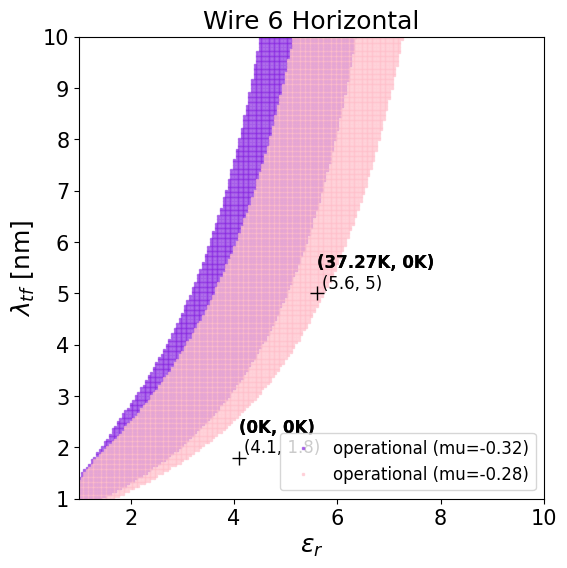

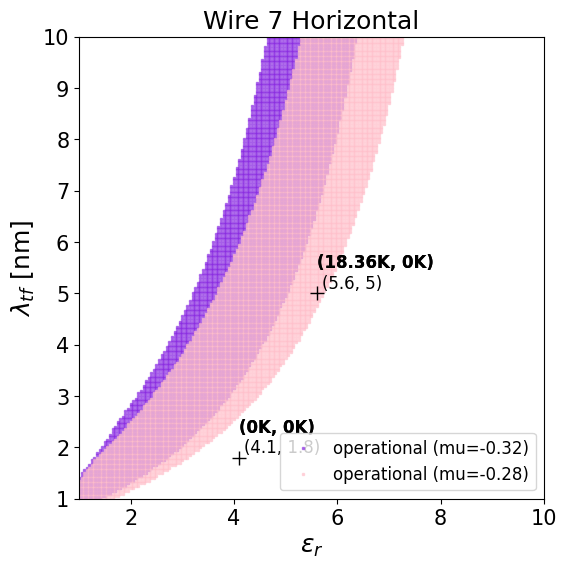

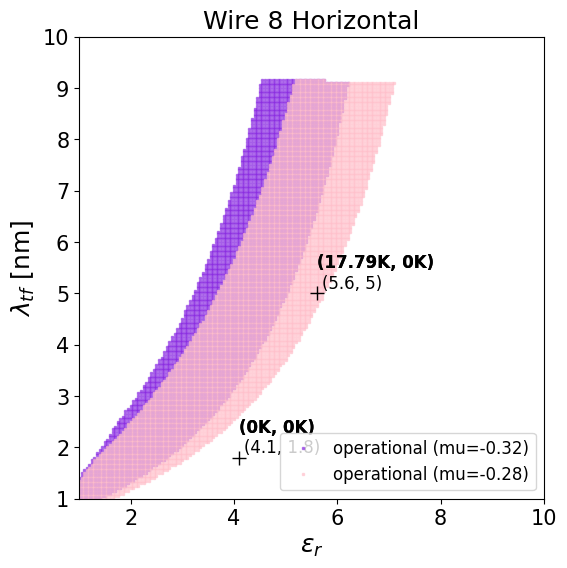

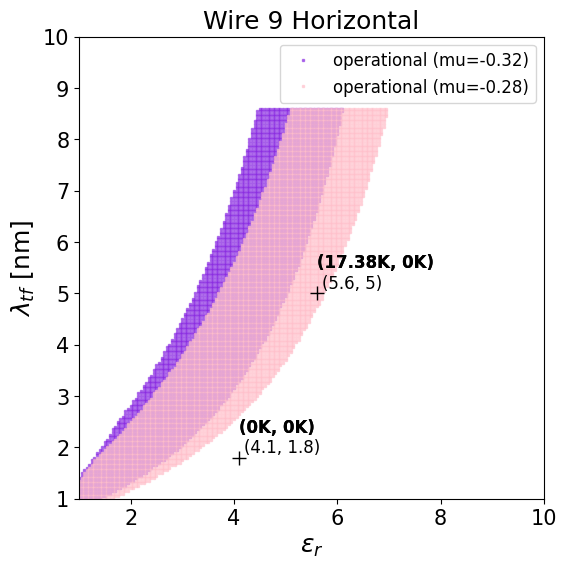

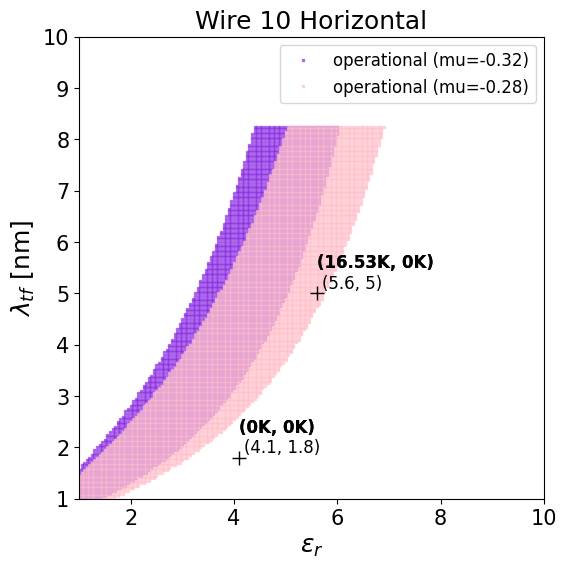

Wire Horizontal Acs gates: ['wire_3_horizontal_ACS', 'wire_4_horizontal_ACS', 'wire_5_horizontal_ACS', 'wire_6_horizontal_ACS', 'wire_7_horizontal_ACS', 'wire_8_horizontal_ACS', 'wire_9_horizontal_ACS', 'wire_10_horizontal_ACS']


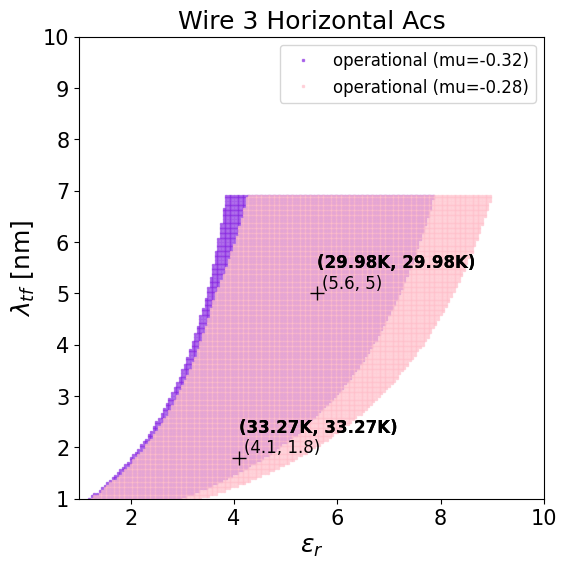

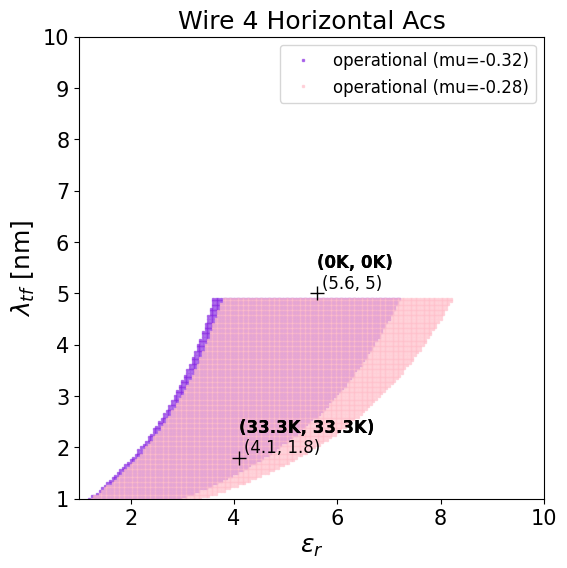

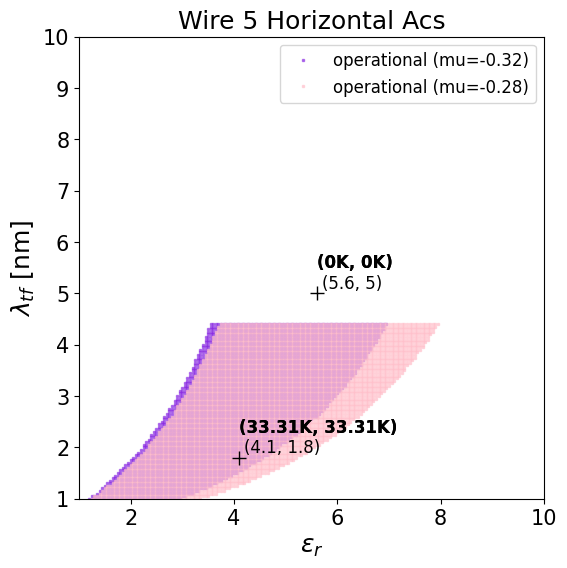

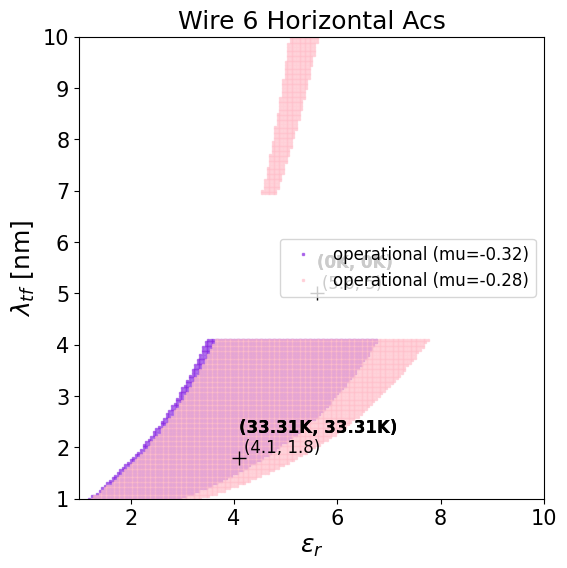

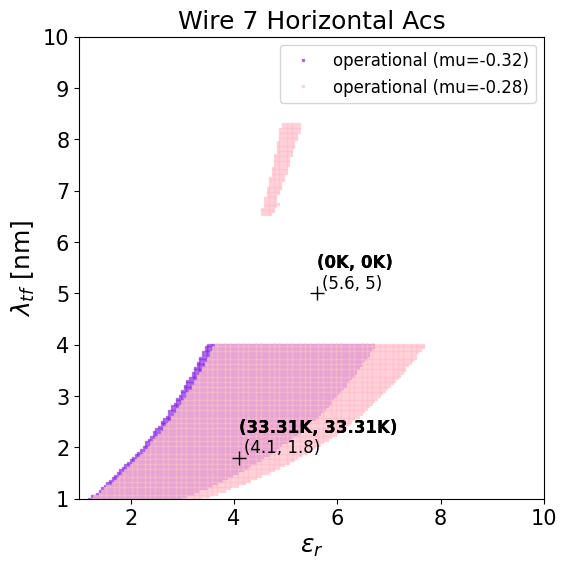

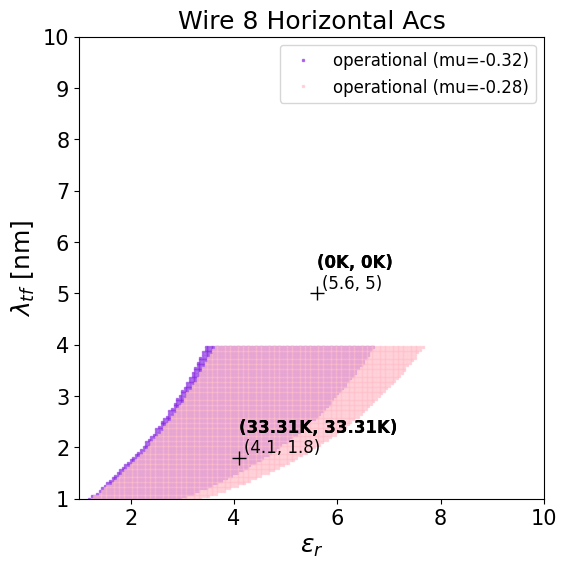

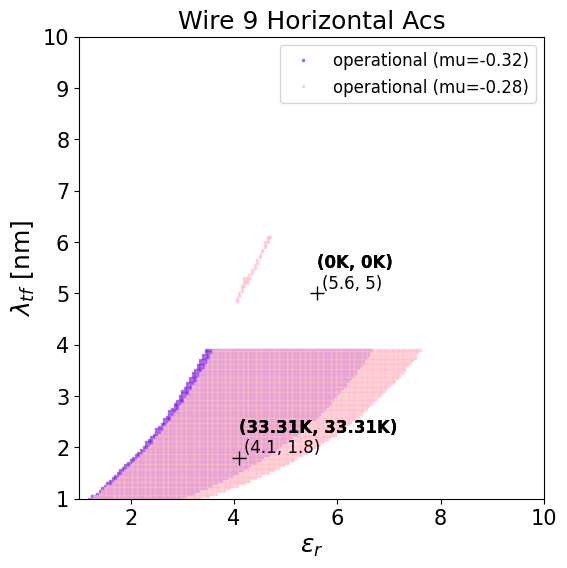

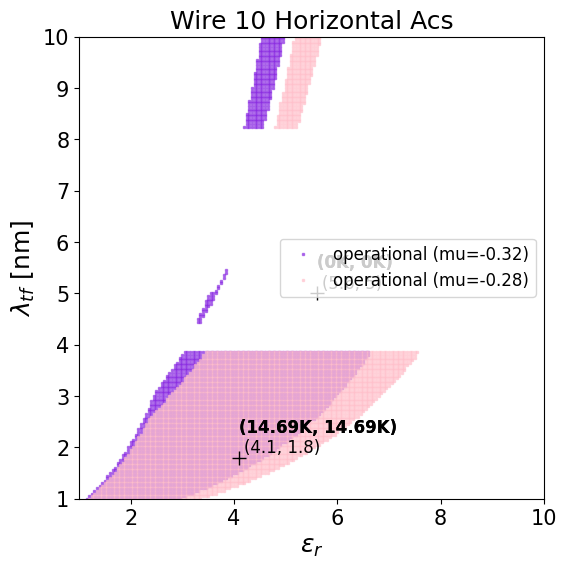

Wire Vertical gates: ['wire_3_vertical', 'wire_4_vertical', 'wire_5_vertical', 'wire_6_vertical', 'wire_7_vertical', 'wire_8_vertical', 'wire_9_vertical', 'wire_10_vertical']


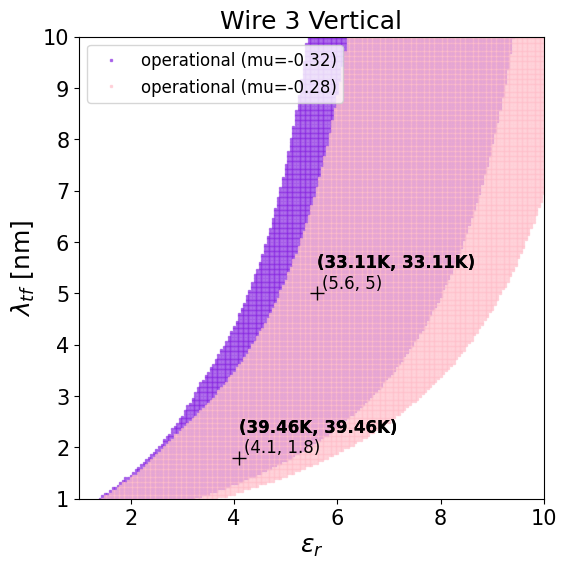

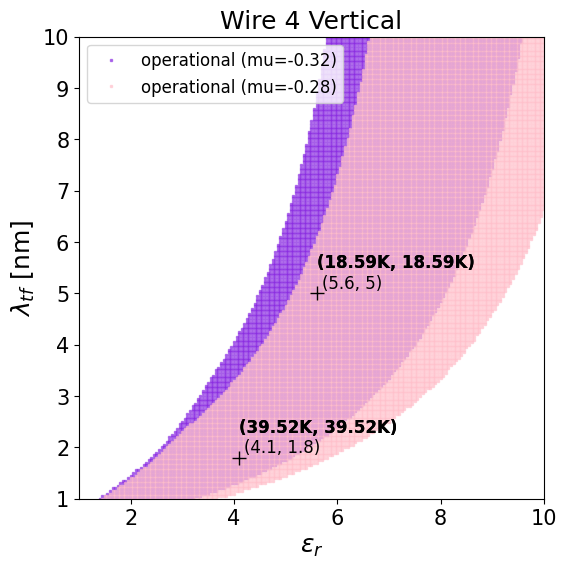

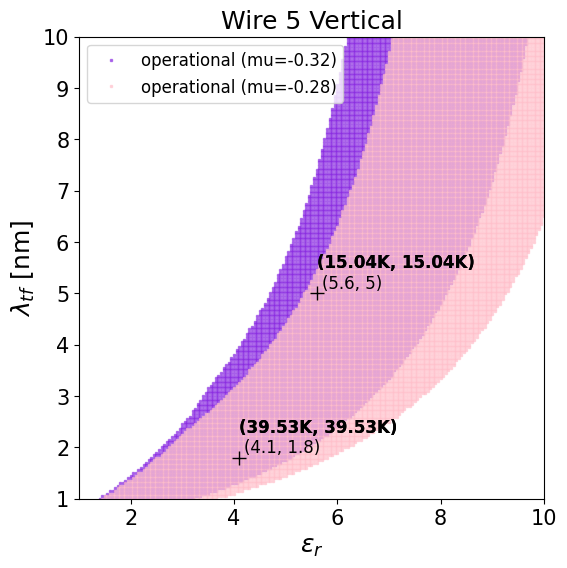

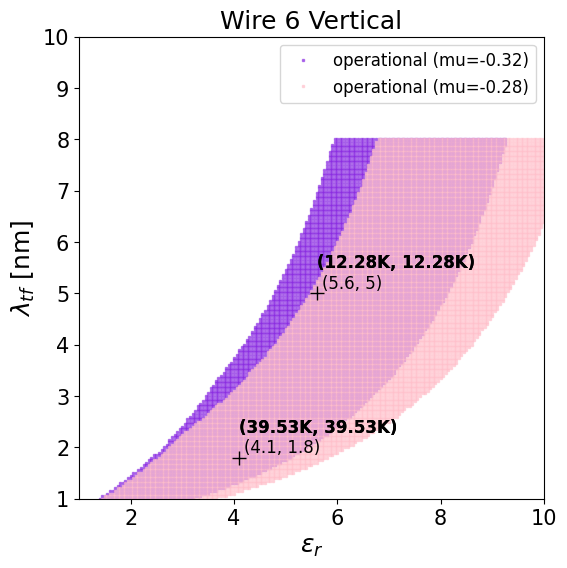

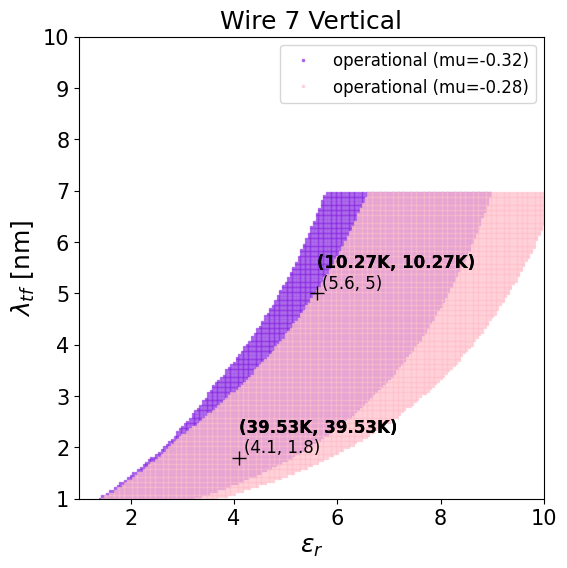

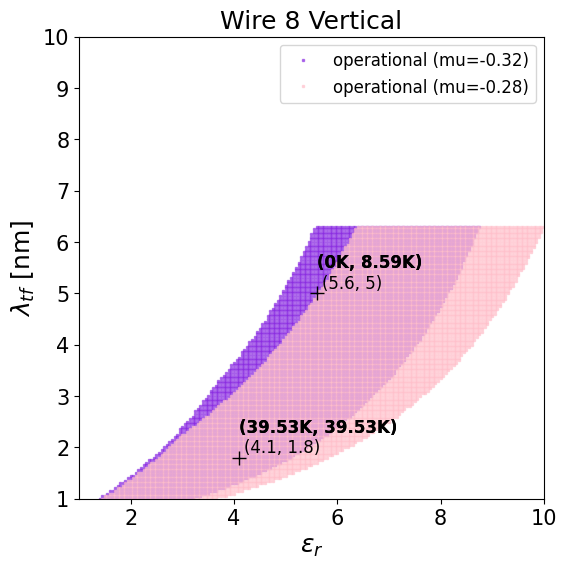

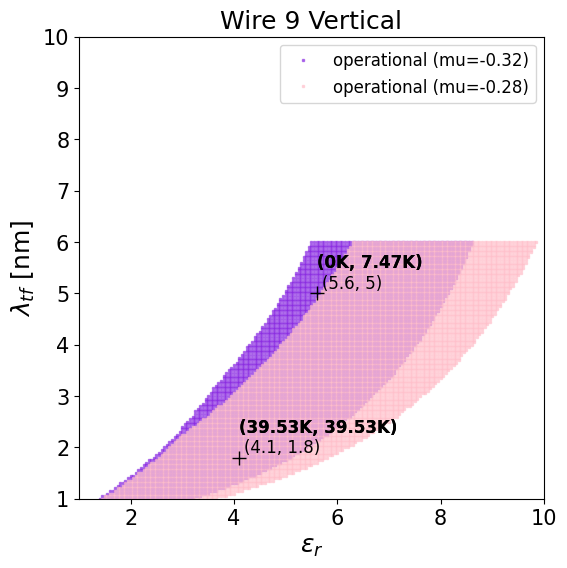

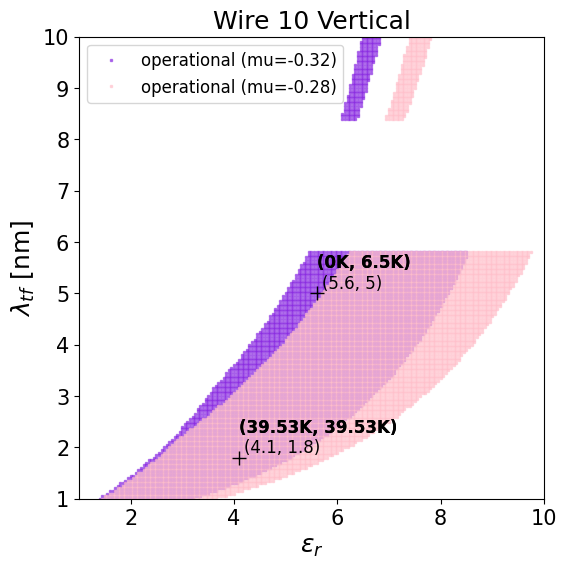

Wire Vertical Old gates: ['wire_3_vertical_Old', 'wire_4_vertical_Old', 'wire_5_vertical_Old', 'wire_6_vertical_Old', 'wire_7_vertical_Old', 'wire_8_vertical_Old', 'wire_9_vertical_Old', 'wire_10_vertical_Old']


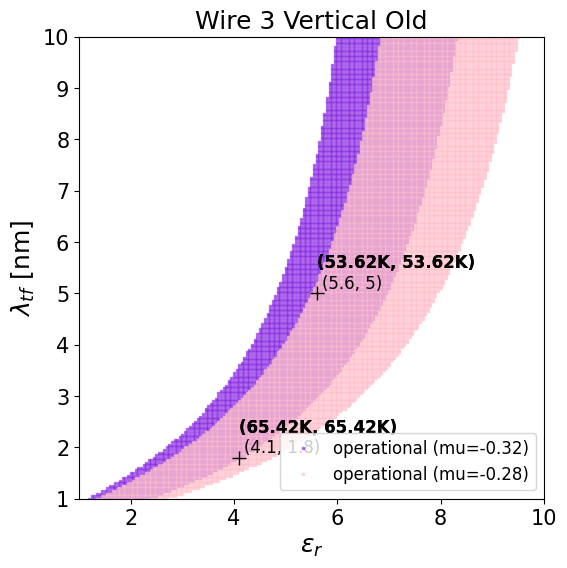

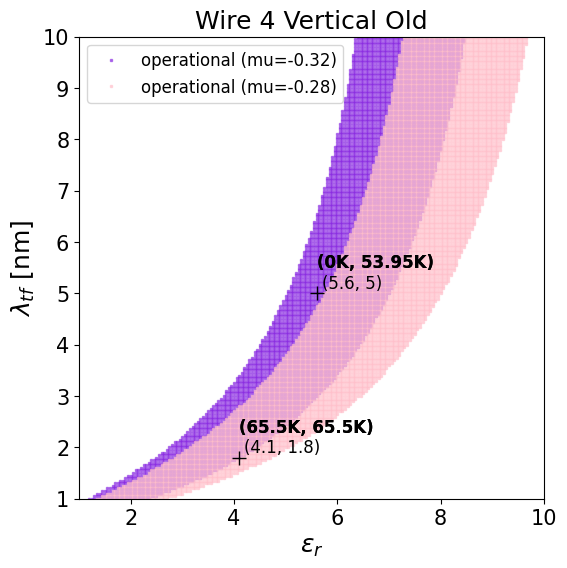

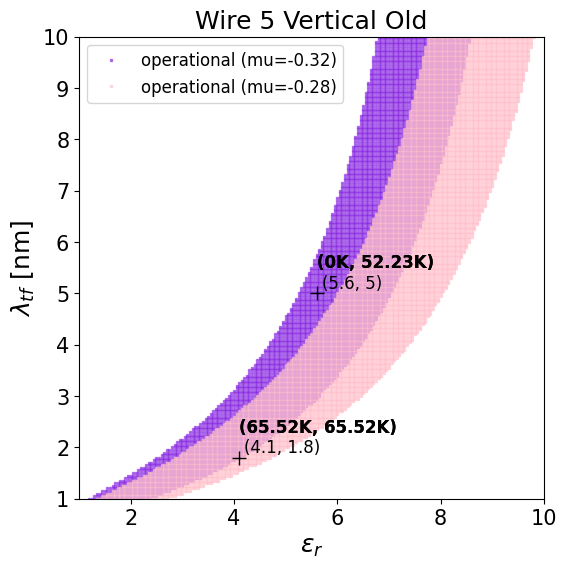

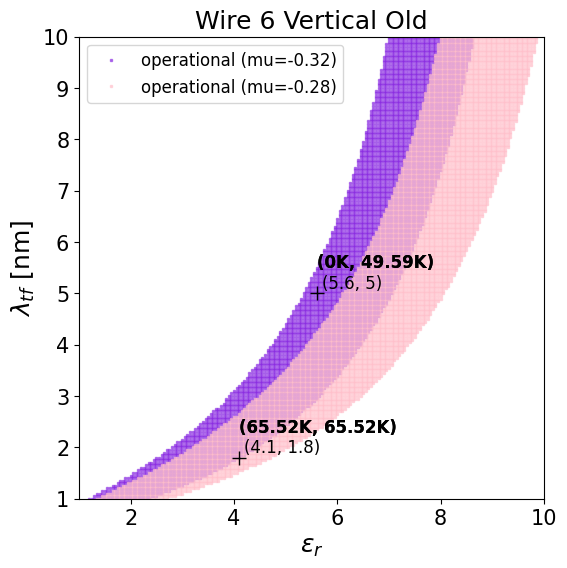

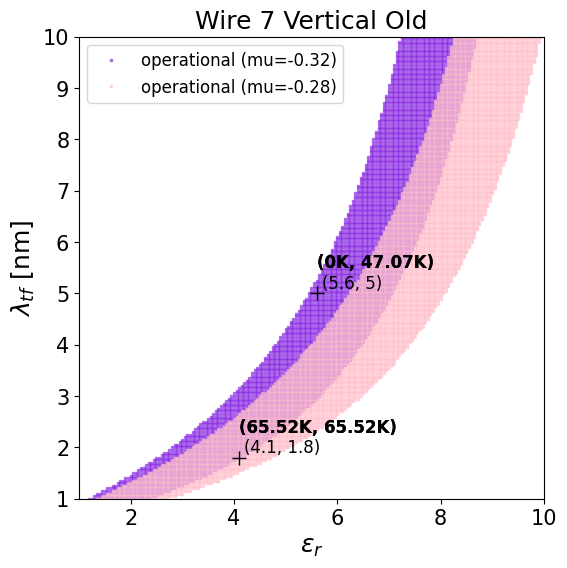

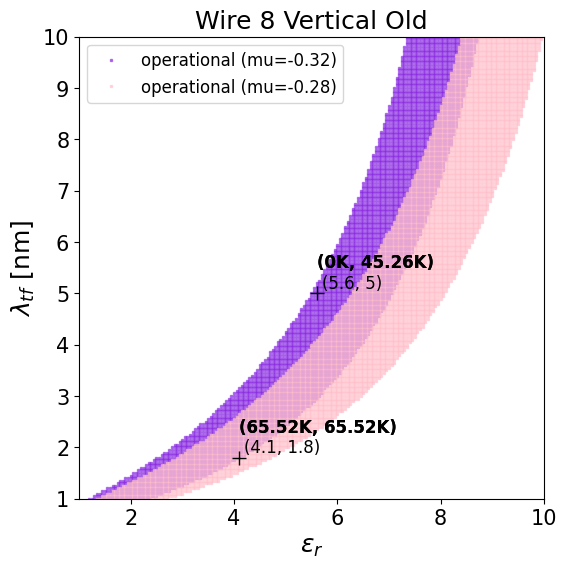

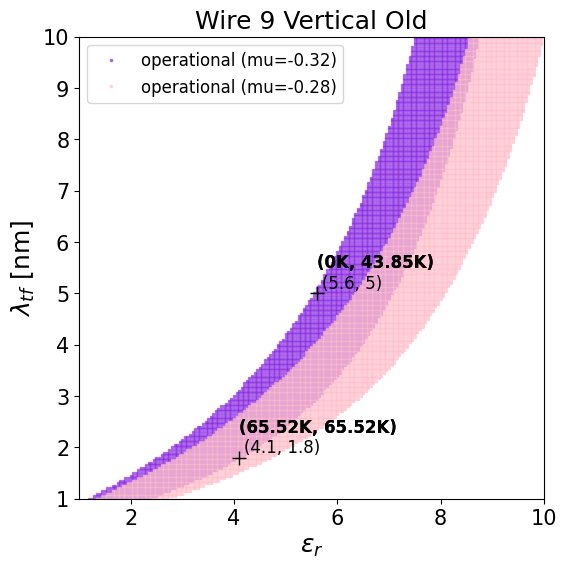

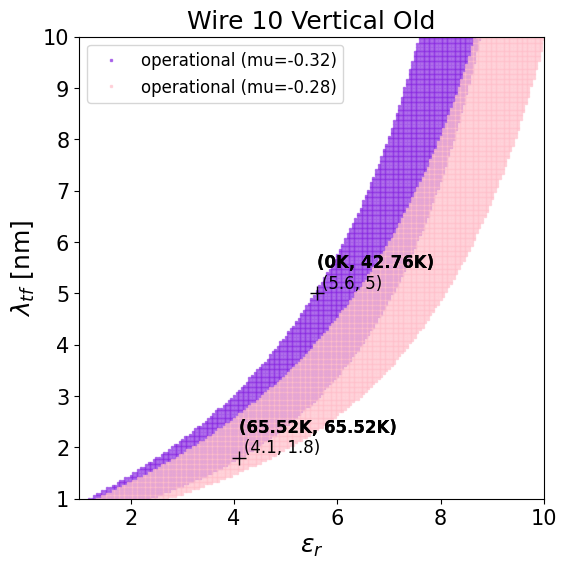

Wire2 Diagonal Acs Far gates: ['wire2_3_diagonal_ACS_far', 'wire2_4_diagonal_ACS_far', 'wire2_5_diagonal_ACS_far', 'wire2_6_diagonal_ACS_far', 'wire2_7_diagonal_ACS_far', 'wire2_8_diagonal_ACS_far', 'wire2_9_diagonal_ACS_far', 'wire2_10_diagonal_ACS_far']


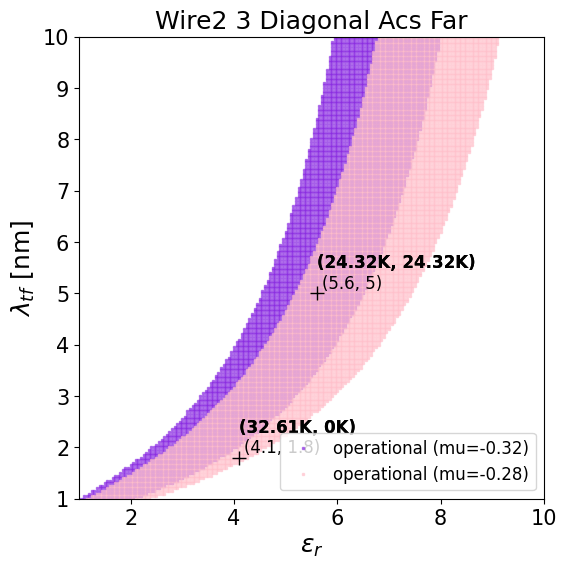

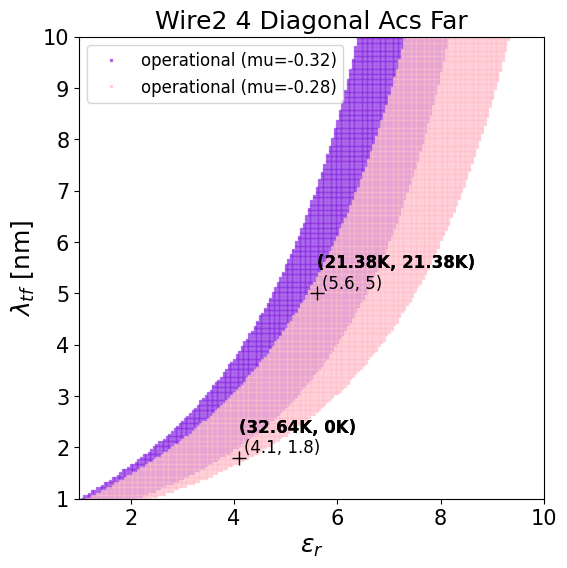

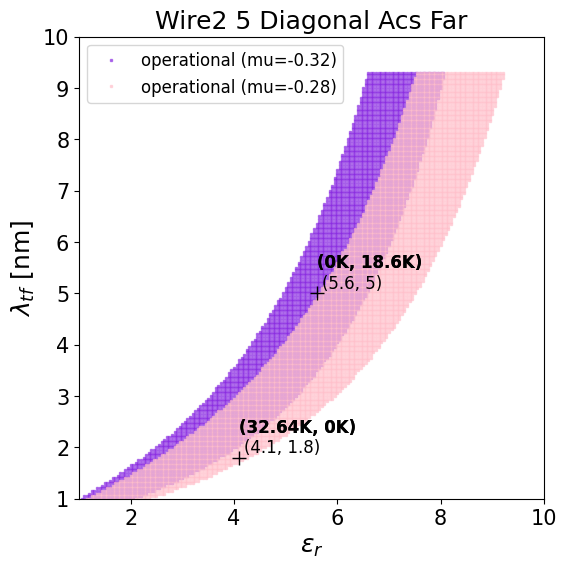

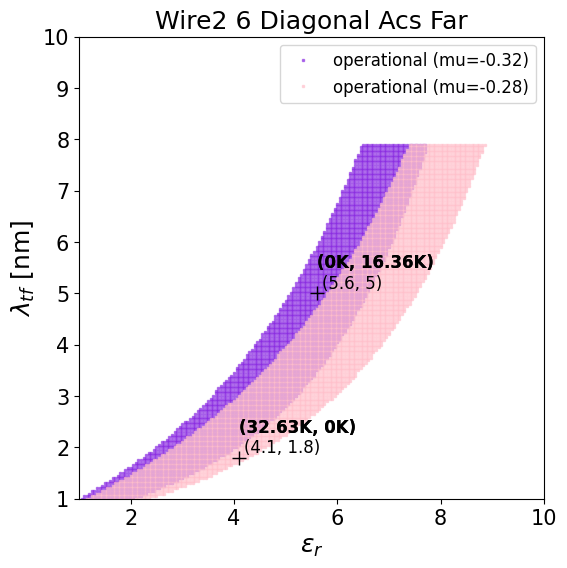

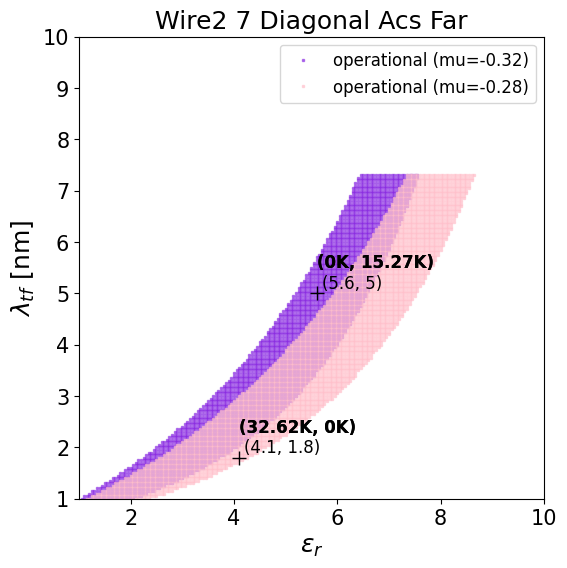

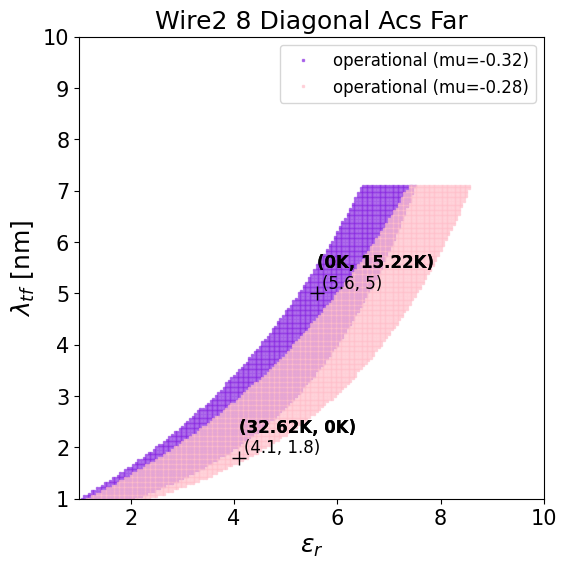

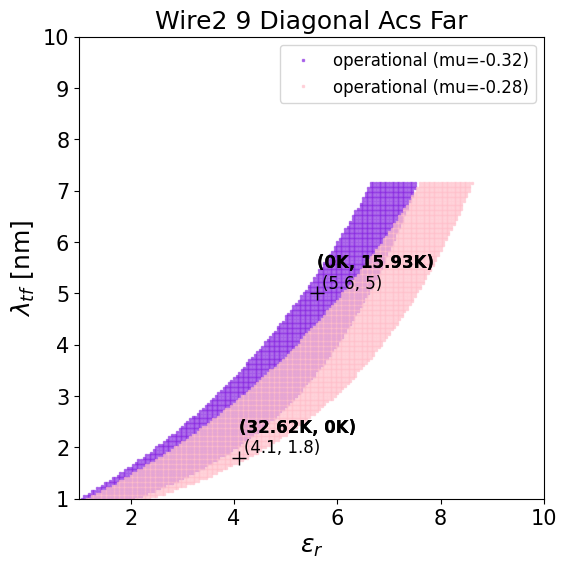

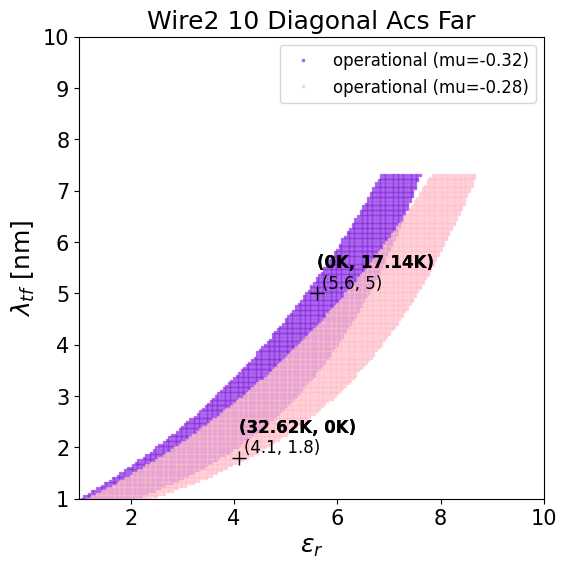

Wire2 Vertical Old gates: ['wire2_3_vertical_Old', 'wire2_4_vertical_Old', 'wire2_5_vertical_Old', 'wire2_6_vertical_Old', 'wire2_7_vertical_Old', 'wire2_8_vertical_Old', 'wire2_9_vertical_Old', 'wire2_10_vertical_Old']


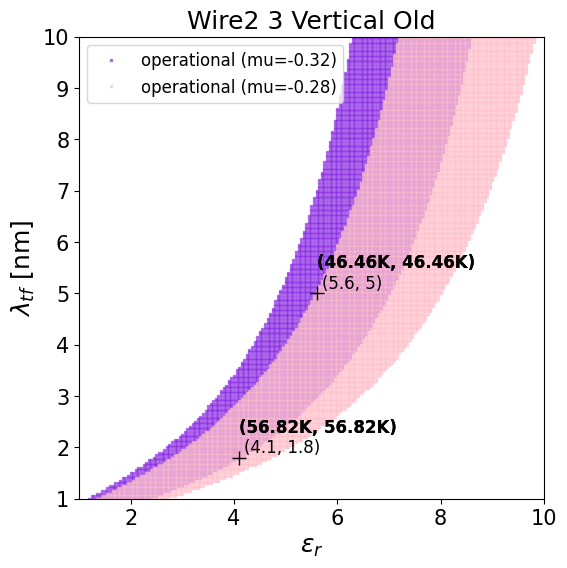

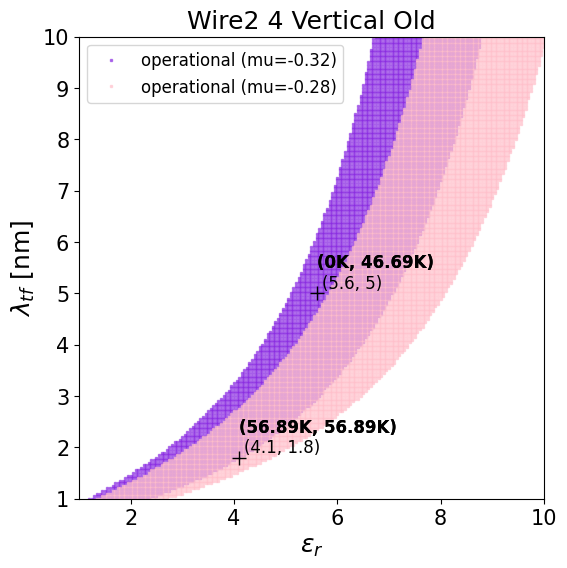

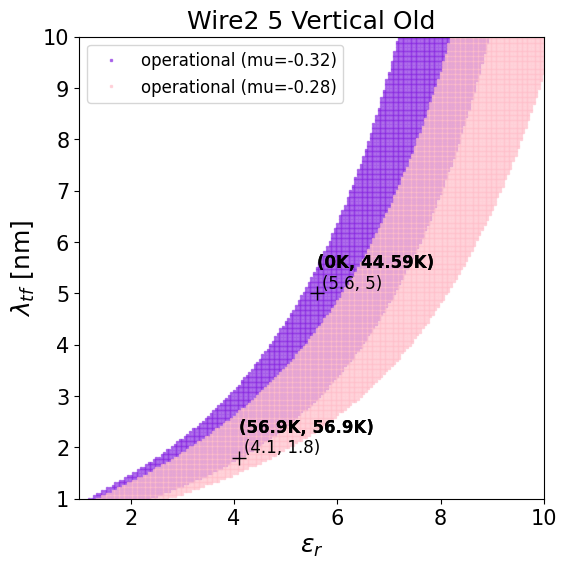

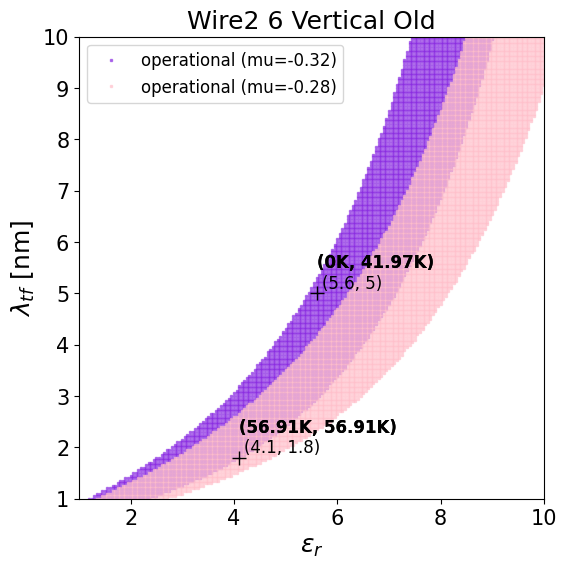

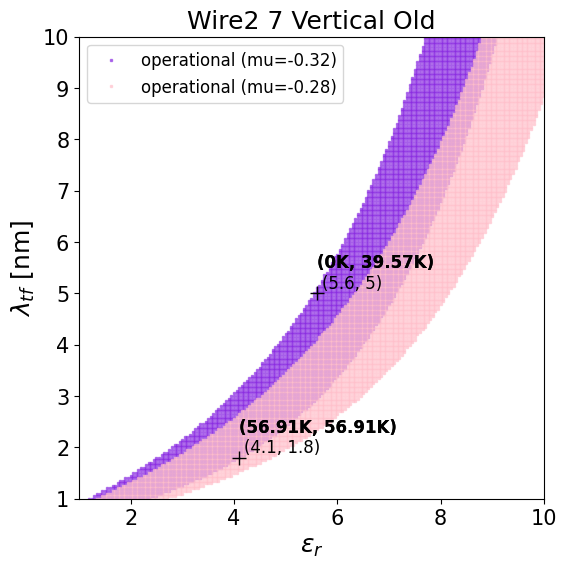

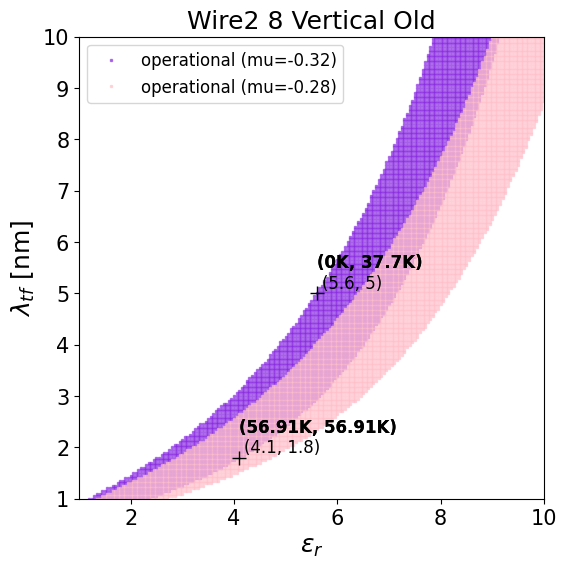

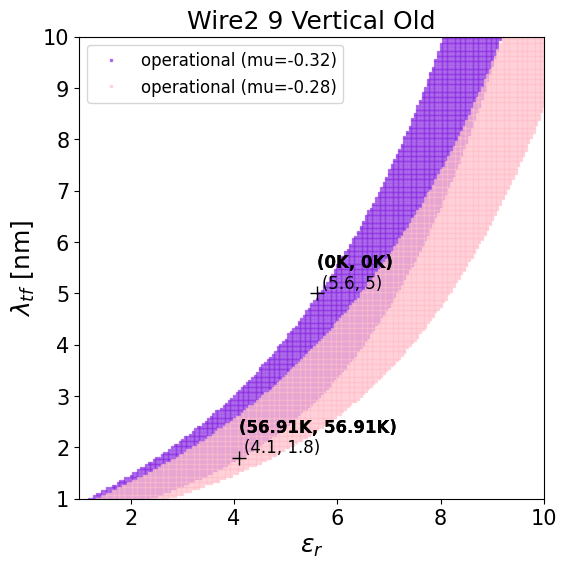

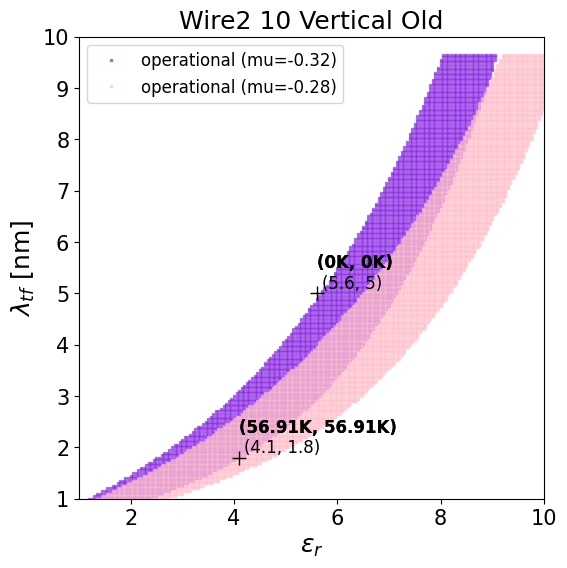

In [18]:
# batches = ["batch_1", "batch_2", "batch_3", "manuel"]

base_path = 'gates/progressive'
batches = [os.path.splitext(file)[0] for file in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, file))]
# batches = ['..']

for batch in batches:
    folder = f"{base_path}/{batch}"
    gates = [os.path.splitext(file)[0] for file in os.listdir(folder) if file.endswith('.sqd')]
    gates.sort()
    # Gambiarra para colocar wire_10 depois do wire_9
    if len(gates) > 1 and (gates[0].startswith("wire_10") or gates[0].startswith("wire2_10")):
        tmp = gates[0]
        gates = gates[1:]
        gates.append(tmp)
    print(f"{batch.replace('_', ' ').title()} gates: {gates}")
    for gate in gates:
        print_operational_domain_epsilon_lambda(folder, gate)

# Produção

In [171]:
# function to print the simulated operational domain
def print_operational_domain_epsilon_lambda_paper(basepath, gates, gate_titles, save_file=None):
    extra_points = [
        (5.6, 5),
        (4.1, 1.8)
    ]
    assert(len(gates) == len(gate_titles) == 6)
    
    mus = [(-0.32, "blueviolet"), (-0.28, "pink")]

    fig, axs = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
    flat_axis = [item for row in axs for item in row]

    plt.grid(False)
    # plt.tick_params(labelsize=15)
    # plt.legend(fontsize=12)
    fig.supxlabel(r'$\epsilon_r$', fontsize=16)
    fig.supylabel(r'$\lambda_{tf}$ [nm]', fontsize=16)

    plots = []
    for (gate, gt, ax) in zip(gates, gate_titles, flat_axis):

        for (mu, color) in mus:
        # Read data from CSV file
            data = None
            try:
                data = pd.read_csv(f"{basepath}/operational_domain_flood_fill_siqad_{mu:.2f}_{gate}.csv")
            except:
                try:
                    data = pd.read_csv(f"{basepath}/operational_domain_contour_tracing_siqad_{mu:.2f}_{gate}.csv")
                except:
                    print(f"Operational Domain file not foungate_titlesd for mu={mu} and gate={gate}.")
                    continue
            
            # Separate data based on operational status
            operational_data = data[data["operational status"] == 1]
            
            # Extract epsilon_r and lambda_tf values for each group
            epsilon_r_operational = operational_data["epsilon_r"]
            lambda_tf_operational = operational_data["lambda_tf"]
            
            # Plot the data with different colors for each group
            plots.append(ax.plot(epsilon_r_operational, lambda_tf_operational, "s", markersize=2, color=color, label=f"Operational for $\mu$={mu:.2f}", alpha=0.4)[0])
        
        ax.set_title(gt, fontsize=14)
        ax.set_xlim(1, 10)
        ax.set_ylim(1, 10)

        cts = [0, 0]
        for (mu, color) in mus:
            temps = pd.read_csv(f"{basepath}/critical_temperature_{mu:.2f}_{gate}.csv")
            cts[0] = max(cts[0], temps.loc[0, 'Critical Temperature (Old)'])
            cts[1] = max(cts[1], (temps.loc[0, 'Critical Temperature (New)']))
        
        for point, ct in zip(extra_points, cts):
            ax.plot(point[0], point[1], "+", markersize=10, color="black")
            ax.text(point[0] + 0.1, point[1] + 0.1, f"({point[0]}, {point[1]})", fontsize=12, color="black")
            ax.text(point[0] + 0.15, point[1] - 0.5, f"CT: {ct}K", fontsize=12, color="black", weight="bold")

    fig.legend(handles=plots[0:2], loc='upper left', bbox_to_anchor=(.55, .965), fontsize=12)
    plt.tight_layout()
    if save_file is not None:
        plt.savefig(save_file, bbox_inches="tight")
    plt.show()

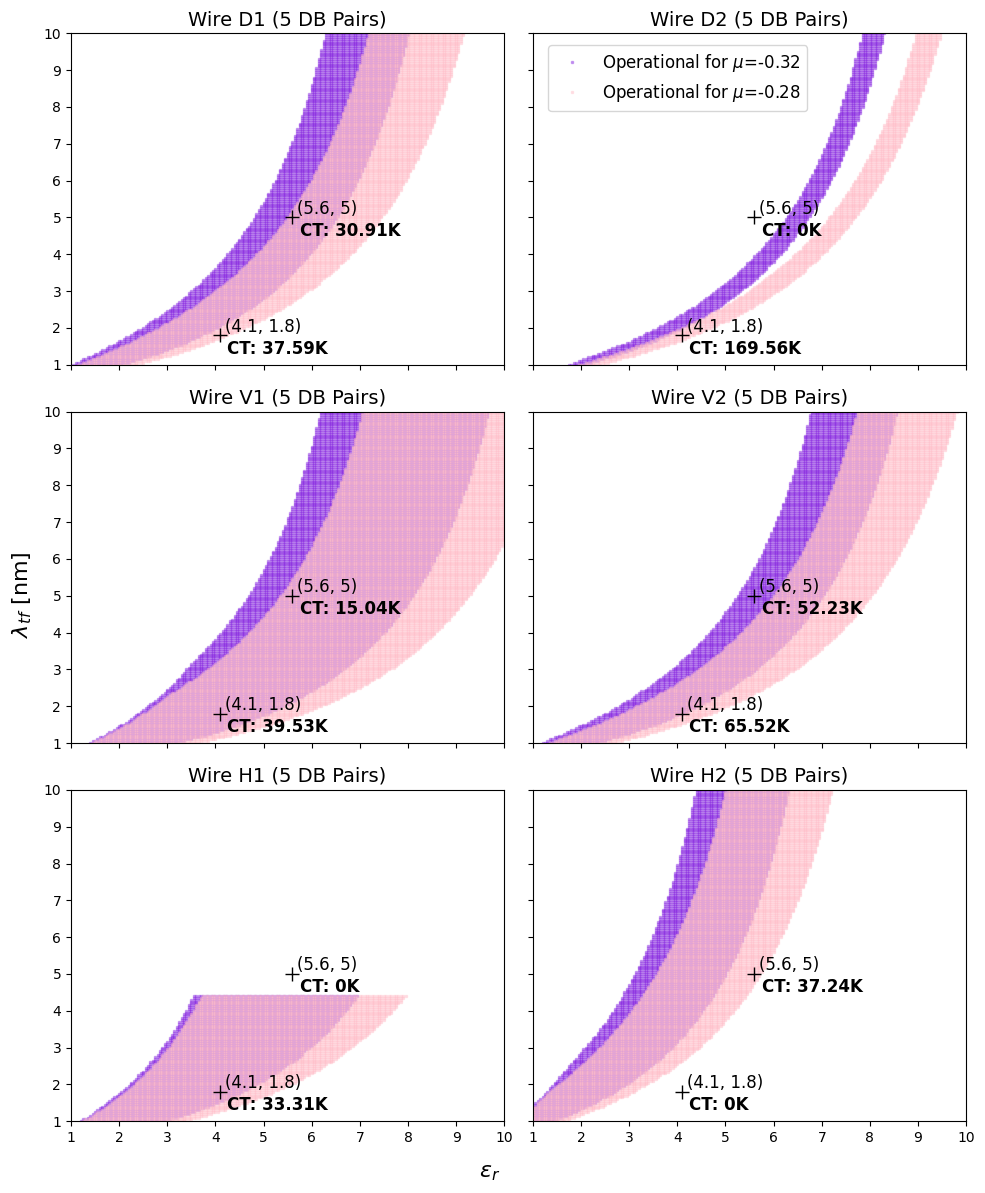

In [173]:
gates = ['wire_5_diagonal_ACS', 'wire_5_diagonal', 'wire_5_vertical', 'wire_5_vertical_Old', 'wire_5_horizontal_ACS', 'wire_5_horizontal']
gate_titles = ['Wire D1 (5 DB Pairs)', 'Wire D2 (5 DB Pairs)', 'Wire V1 (5 DB Pairs)', 'Wire V2 (5 DB Pairs)', 'Wire H1 (5 DB Pairs)', 'Wire H2 (5 DB Pairs)']

print_operational_domain_epsilon_lambda_paper('gates/paper', gates, gate_titles, 'results.png')

# Área do Operational Domain

In [19]:
# function to print the simulated operational domain
def calculate_area_od(basepath, gate):
    mus=[-0.32, -0.28]
    values = []
    for mu in mus:
        data = None
        try:
            data = pd.read_csv(f"{basepath}/operational_domain_flood_fill_siqad_{mu:.2f}_{gate}.csv")
        except:
            print(f"Operational Domain file not found for mu={mu} and gate={gate}.")
            continue
        
        # Separate data based on operational status
        values.append((mu, len(data[data["operational status"] == 1])/32400.0))
    print(f"Gate: {gate}. Operational domain area: {values}")

In [20]:
# batches = ["batch_1", "batch_2", "batch_3", "manuel"]

base_path = 'gates/progressive'
batches = [os.path.splitext(file)[0] for file in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, file))]
# batches = ['..']

for batch in batches:
    folder = f"{base_path}/{batch}"
    gates = [os.path.splitext(file)[0] for file in os.listdir(folder) if file.endswith('.sqd')]
    gates.sort()
    # Gambiarra para colocar wire_10 depois do wire_9
    if len(gates) > 1 and (gates[0].startswith("wire_10") or gates[0].startswith("wire2_10")):
        tmp = gates[0]
        gates = gates[1:]
        gates.append(tmp)
    print(f"{batch.replace('_', ' ').title()} gates: {gates}")
    for gate in gates:
        calculate_area_od(folder, gate)

Wire2 Horizontal Acs gates: ['wire2_3_horizontal_ACS', 'wire2_4_horizontal_ACS', 'wire2_5_horizontal_ACS', 'wire2_6_horizontal_ACS', 'wire2_7_horizontal_ACS', 'wire2_8_horizontal_ACS', 'wire2_9_horizontal_ACS', 'wire2_10_horizontal_ACS']
Gate: wire2_3_horizontal_ACS. Operational domain area: [(-0.32, 0.1095679012345679), (-0.28, 0.13327160493827162)]
Gate: wire2_4_horizontal_ACS. Operational domain area: [(-0.32, 0.07935185185185185), (-0.28, 0.0974074074074074)]
Gate: wire2_5_horizontal_ACS. Operational domain area: [(-0.32, 0.0724074074074074), (-0.28, 0.08925925925925926)]
Gate: wire2_6_horizontal_ACS. Operational domain area: [(-0.32, 0.0682716049382716), (-0.28, 0.0837962962962963)]
Gate: wire2_7_horizontal_ACS. Operational domain area: [(-0.32, 0.06623456790123457), (-0.28, 0.08120370370370371)]
Gate: wire2_8_horizontal_ACS. Operational domain area: [(-0.32, 0.06416666666666666), (-0.28, 0.0787962962962963)]
Gate: wire2_9_horizontal_ACS. Operational domain area: [(-0.32, 0.064074